In [1]:
import joblib
import pandas as pd
import duckdb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the fresh "Honest" Model
pipeline = joblib.load('../data/processed/biocascade_model.joblib')

# 2. Re-pull the ground truth from the database to ensure sync
con = duckdb.connect('../data/processed/biocascade.db')
df_full = con.execute("SELECT * FROM feature_matrix_raw").df()

# 3. Define the exact features your model expects
features = ['age', 'diastolic_bp', 'log_triglycerides']
X = df_full[features]
y = df_full['is_high_risk']

# 4. Split using the same random seed as your src/model.py
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Re-synced with {len(X_test)} test samples.")
print(f"Features in use: {pipeline.feature_names_in_.tolist()}")

✅ Re-synced with 915 test samples.
Features in use: ['age', 'diastolic_bp', 'log_triglycerides']


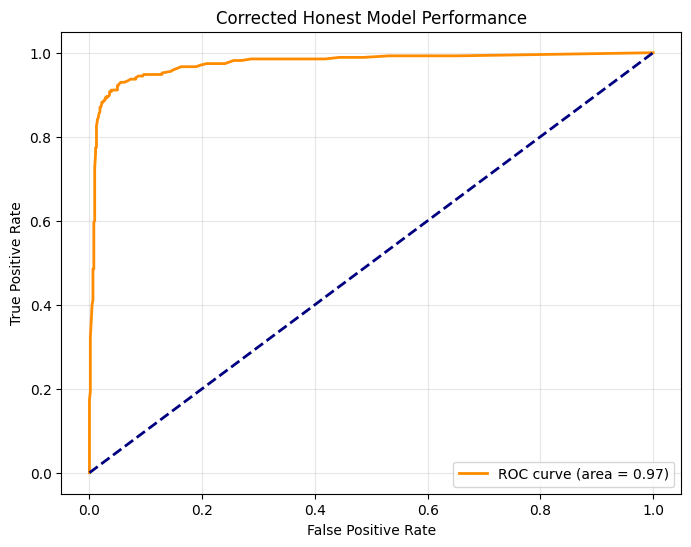

In [2]:
# Get prediction probabilities for the 'High Risk' class
y_probs = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Corrected Honest Model Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

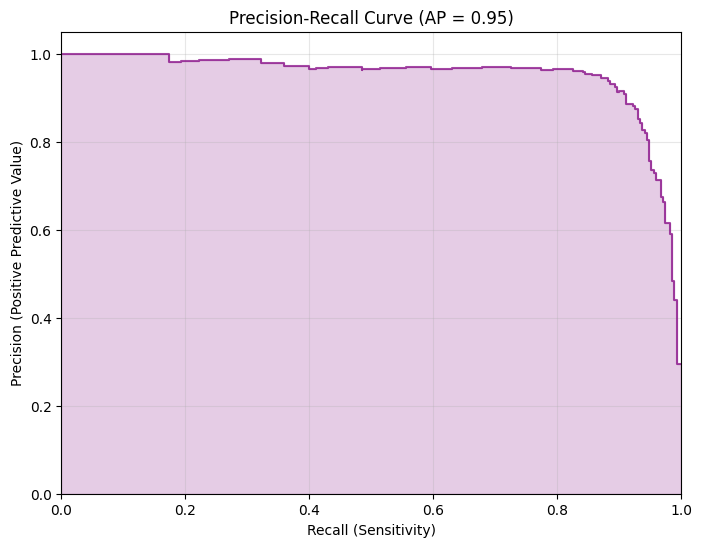

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='purple', alpha=0.7, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='purple')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title(f'Precision-Recall Curve (AP = {avg_precision:.2f})')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Patient Classification Counts')
plt.show()